In [1]:
# Setup imports and module paths so notebook can reuse app code
from pathlib import Path
import os
import sys

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path.cwd().resolve().parent
app_dir = repo_root / "app"

if str(app_dir) not in sys.path:
    sys.path.insert(0, str(app_dir))

import load_functions as lf
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

print(f"Repo root: {repo_root}")
print(f"App dir added: {app_dir}")

Repo root: /home/barradd/Documents/GitHub/Coral-CAT-Coral-Color-Assessment-Tool
App dir added: /home/barradd/Documents/GitHub/Coral-CAT-Coral-Color-Assessment-Tool/app


In [2]:
# Inputs
images_list = [
    '../data/interim/coral_frag_to_test_bug_1.jpeg',
    '../data/interim/coral_frag_to_test_bug_2.jpeg',
]
color_chart_to_map = '../data/interim/custom_color_chart_buggy_image.txt'

print('Images:')
for p in images_list:
    print(f'  - {p}')
print(f'Color chart: {color_chart_to_map}')

Images:
  - ../data/interim/coral_frag_to_test_bug_1.jpeg
  - ../data/interim/coral_frag_to_test_bug_2.jpeg
Color chart: ../data/interim/custom_color_chart_buggy_image.txt


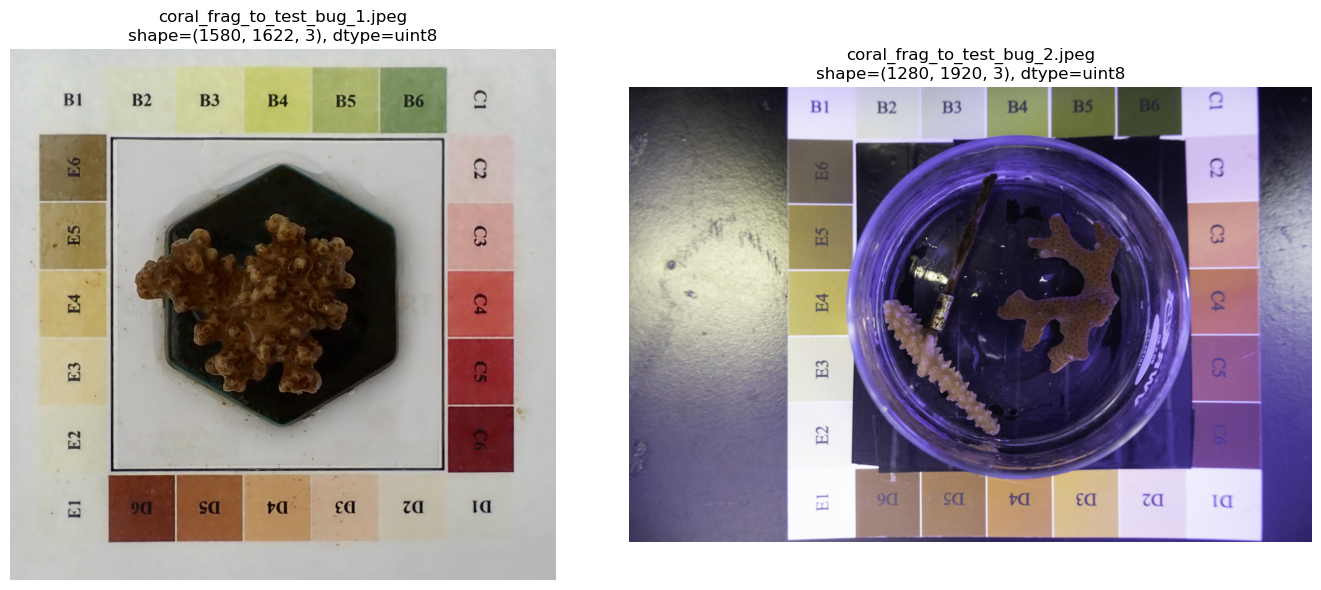

Loaded 2 images
Loaded 26 chart colors


,color_name,rgb
0,B1,"(210, 214, 207)"
1,B2,"(208, 212, 189)"
2,B3,"(209, 211, 160)"
3,B4,"(196, 199, 113)"
4,B5,"(169, 179, 110)"
5,B6,"(121, 143, 94)"
6,D1,"(187, 187, 179)"
7,D2,"(189, 183, 165)"
8,D3,"(189, 164, 136)"
9,D4,"(182, 140, 94)"


In [3]:
# Load the two images and parse the custom color chart

def parse_color_chart_txt(path):
    chart = {}
    with open(path, 'r', encoding='utf-8') as f:
        for raw in f:
            line = raw.strip()
            if not line or ':' not in line:
                continue
            key, value = line.split(':', 1)
            key = key.strip()
            rgb = value.strip().replace('(', '').replace(')', '')
            parts = [p.strip() for p in rgb.split(',') if p.strip()]
            if len(parts) != 3:
                continue
            chart[key] = tuple(int(x) for x in parts)
    return chart

loaded_images = {}
for img_path in images_list:
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        raise FileNotFoundError(f'Could not read image: {img_path}')
    loaded_images[img_path] = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

custom_color_chart = parse_color_chart_txt(color_chart_to_map)
if not custom_color_chart:
    raise ValueError('Custom color chart is empty or could not be parsed.')

fig, axes = plt.subplots(1, len(loaded_images), figsize=(14, 6))
if len(loaded_images) == 1:
    axes = [axes]

for ax, (name, img) in zip(axes, loaded_images.items()):
    ax.imshow(img)
    ax.set_title(f"{os.path.basename(name)}\nshape={img.shape}, dtype={img.dtype}")
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f'Loaded {len(loaded_images)} images')
print(f'Loaded {len(custom_color_chart)} chart colors')
pd.DataFrame([
    {'color_name': k, 'rgb': v} for k, v in custom_color_chart.items()
]).head(10)

In [4]:
# Segment both images with CoralSCOP (same params as app page 7)
# Note: CoralSCOP weights are in app/checkpoints in this repo layout.
checkpoint_path = str((repo_root / 'app' / 'checkpoints' / 'vit_b_coralscop.pth').resolve())
model_type = 'vit_b'

def build_generator(sam_model, crop_n_layers):
    return SamAutomaticMaskGenerator(
        model=sam_model,
        points_per_side=32,
        pred_iou_thresh=0.72,
        stability_score_thresh=0.62,
        crop_n_layers=crop_n_layers,
        crop_n_points_downscale_factor=2,
        min_mask_region_area=100,
    )

device = 'cuda' if lf.torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
print(f'Checkpoint: {checkpoint_path}')

if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f'Checkpoint not found: {checkpoint_path}')

sam = sam_model_registry[model_type](checkpoint=checkpoint_path)
sam.to(device=device)

masks_by_image = {}
for image_name, image_rgb in loaded_images.items():
    try:
        # First try the same setting used by the Streamlit app.
        mask_generator = build_generator(sam, crop_n_layers=1)
        masks = mask_generator.generate(image_rgb)
        print(f"{os.path.basename(image_name)} -> {len(masks)} masks (crop_n_layers=1)")
    except Exception as e:
        print(f"{os.path.basename(image_name)} failed with crop_n_layers=1: {e}")
        print("Falling back to crop_n_layers=0 for robustness on this debug run.")
        mask_generator = build_generator(sam, crop_n_layers=0)
        masks = mask_generator.generate(image_rgb)
        print(f"{os.path.basename(image_name)} -> {len(masks)} masks (crop_n_layers=0)")

    if len(masks) == 0:
        raise RuntimeError(f"No masks generated for {image_name}")

    masks_by_image[image_name] = masks

Using device: cuda
Checkpoint: /home/barradd/Documents/GitHub/Coral-CAT-Coral-Color-Assessment-Tool/app/checkpoints/vit_b_coralscop.pth
loading from /home/barradd/Documents/GitHub/Coral-CAT-Coral-Color-Assessment-Tool/app/checkpoints/vit_b_coralscop.pth


/home/barradd/Documents/GitHub/Coral-CAT-Coral-Color-Assessment-Tool/app/segment_anything/build_sam.py:113: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.

coral_frag_to_test_bug_1.jpeg -> 4 masks (crop_n_layers=1)
coral_frag_to_test_bug_2.jpeg -> 2 masks (crop_n_layers=1)



coral_frag_to_test_bug_1.jpeg top candidates:


,candidate_index,mask_number,area
0,0,2,201598
1,1,3,200589
2,2,0,38565
3,3,1,38006


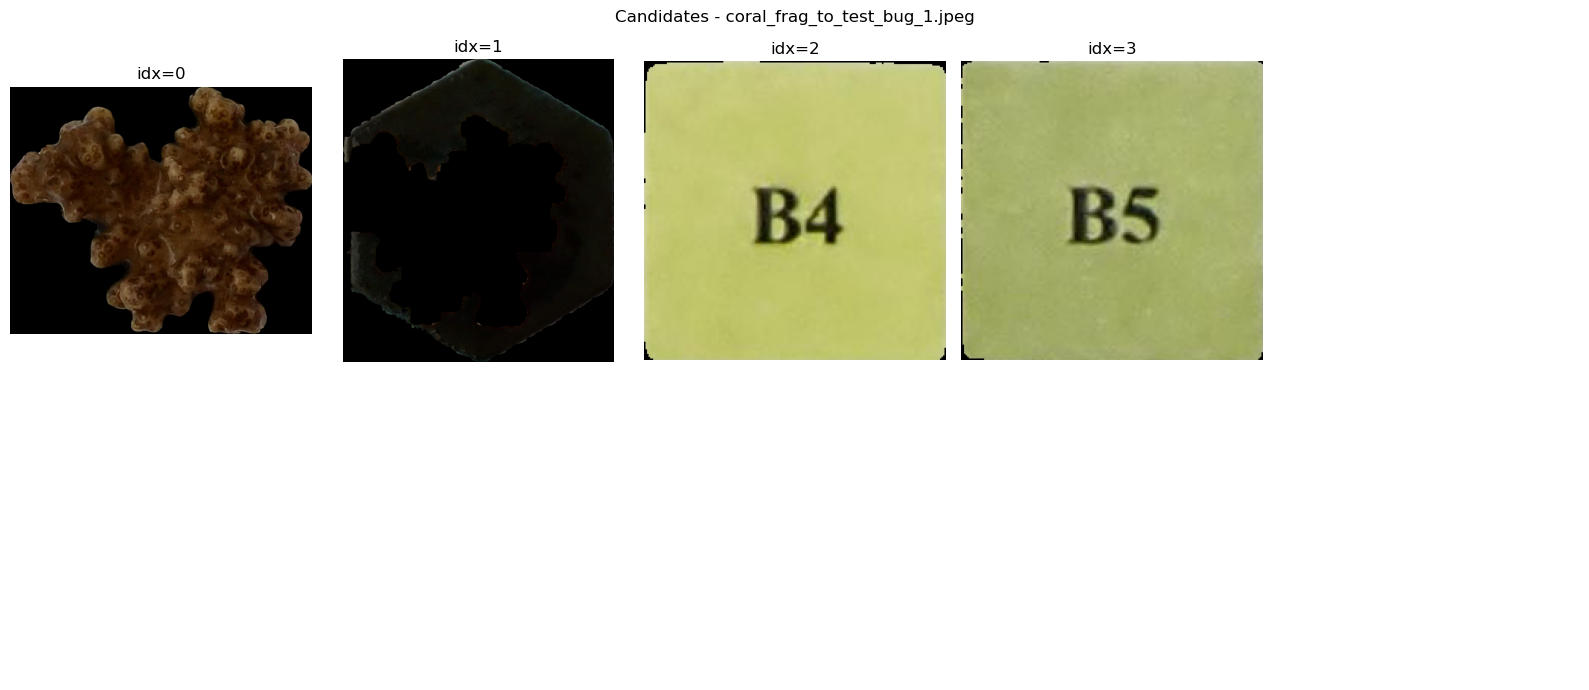


coral_frag_to_test_bug_2.jpeg top candidates:


,candidate_index,mask_number,area
0,0,0,63901
1,1,1,31501


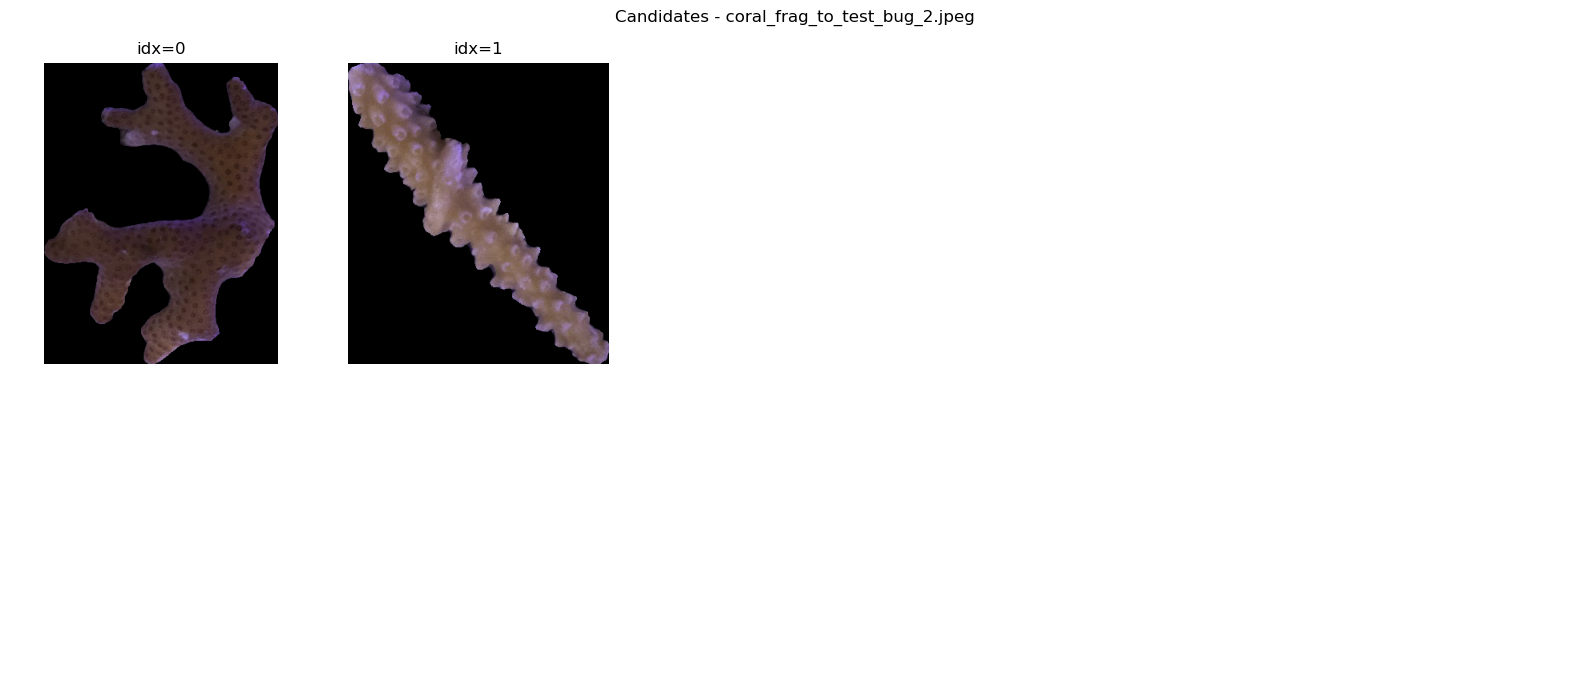

Selected candidate index per image:
  - coral_frag_to_test_bug_1.jpeg: 0
  - coral_frag_to_test_bug_2.jpeg: 0


In [5]:
# Inspect top candidate segmented crops and choose mask index manually for each image
candidate_crops_by_image = {}
candidate_masks_by_image = {}
candidate_tables = {}

for image_name, image_rgb in loaded_images.items():
    masks = masks_by_image[image_name]
    crop_list, _titles, foreground_masks = lf.process_images(
        image=image_rgb,
        masks=masks,
        return_foreground_masks=True,
    )

    image_df, _crop_dict, _mask_pix = lf.get_sorted_by_area(image=image_rgb, anns=masks)
    top_df = image_df.head(10).copy().reset_index(drop=True)
    top_df['candidate_index'] = top_df.index

    candidate_crops_by_image[image_name] = crop_list
    candidate_masks_by_image[image_name] = foreground_masks
    candidate_tables[image_name] = top_df

    print(f"\n{os.path.basename(image_name)} top candidates:")
    display(top_df[['candidate_index', 'mask_number', 'area']])

    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    axes = axes.flatten()
    for i, ax in enumerate(axes):
        if i < len(crop_list):
            ax.imshow(crop_list[i])
            ax.set_title(f"idx={i}")
        ax.axis('off')
    plt.suptitle(f"Candidates - {os.path.basename(image_name)}")
    plt.tight_layout()
    plt.show()

# Manual choice per image (edit values if needed)
selected_candidate_index = {
    list(loaded_images.keys())[0]: 0,
    list(loaded_images.keys())[1]: 0,
}

selected_segmented_crops = {}
selected_segmented_masks = {}
for image_name, idx in selected_candidate_index.items():
    crops = candidate_crops_by_image[image_name]
    masks = candidate_masks_by_image[image_name]
    if idx < 0 or idx >= len(crops):
        raise IndexError(f"Invalid selected index {idx} for image {image_name}")
    selected_segmented_crops[image_name] = crops[idx]
    selected_segmented_masks[image_name] = masks[idx]

print('Selected candidate index per image:')
for k, v in selected_candidate_index.items():
    print(f"  - {os.path.basename(k)}: {v}")

In [6]:
# Compute Euclidean distance to chart colors, then map closest chart colors to each selected segmented crop
analysis_rows = []
mapped_images = {}

for image_name, seg_img in selected_segmented_crops.items():
    print(f"\nAnalyzing: {os.path.basename(image_name)}")
    fg_mask = selected_segmented_masks[image_name]

    color_keys_selected, color_selected_distance, lower_y_limit, higher_y_limit, hex_colors_map = lf.calculate_distances_to_colors(
        image=seg_img,
        custom_color_chart=custom_color_chart,
        foreground_mask=fg_mask,
    )

    # Show distance plot from existing app helper
    lf.plot_compare(
        seg_img,
        color_keys_selected,
        color_selected_distance,
        lower_y_limit,
        higher_y_limit,
        hex_colors_map,
        title=f"{os.path.basename(image_name)} - Selected Segment",
    )

    # Create mapped image with closest chart colors and show distribution
    lf.plot_compare_mapped_image(seg_img, custom_color_chart, foreground_mask=fg_mask)

    # Also capture mapped array for debugging
    mapped_img, _color_map, color_to_pixels = lf.map_color_to_pixels(
        seg_img,
        custom_color_chart,
        foreground_mask=fg_mask,
    )
    mapped_images[image_name] = mapped_img

    # Summarize closest color results
    for rank, (ckey, dist) in enumerate(zip(color_keys_selected, color_selected_distance), start=1):
        analysis_rows.append(
            {
                'image': os.path.basename(image_name),
                'selected_candidate_index': selected_candidate_index[image_name],
                'rank': rank,
                'closest_color': ckey,
                'distance': float(dist),
            }
        )

summary_df = pd.DataFrame(analysis_rows)
summary_df


Analyzing: coral_frag_to_test_bug_1.jpeg


2026-04-30 17:02:28.872 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 17:02:28.873 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 17:02:28.881 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 17:02:29.075 
  command:

    streamlit run /home/barradd/Documents/GitHub/Coral-CAT-Coral-Color-Assessment-Tool/env/lib/python3.12/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-04-30 17:02:29.076 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 17:02:29.082 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runnin


Analyzing: coral_frag_to_test_bug_2.jpeg


2026-04-30 17:02:32.634 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 17:02:32.635 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 17:02:32.639 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 17:02:32.640 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 17:02:32.642 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 17:02:32.642 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 17:02:32.643 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 17:02:32.643 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

,image,selected_candidate_index,rank,closest_color,distance
0,coral_frag_to_test_bug_1.jpeg,0,1,D6,18.684512
1,coral_frag_to_test_bug_1.jpeg,0,2,D5,26.832064
2,coral_frag_to_test_bug_1.jpeg,0,3,C6,26.928906
3,coral_frag_to_test_bug_1.jpeg,0,4,E6,27.002831
4,coral_frag_to_test_bug_1.jpeg,0,5,Black,31.689006
5,coral_frag_to_test_bug_2.jpeg,0,1,D6,28.782992
6,coral_frag_to_test_bug_2.jpeg,0,2,Black,31.142080
7,coral_frag_to_test_bug_2.jpeg,0,3,C6,31.686038
8,coral_frag_to_test_bug_2.jpeg,0,4,E6,37.207114
9,coral_frag_to_test_bug_2.jpeg,0,5,D5,40.109818


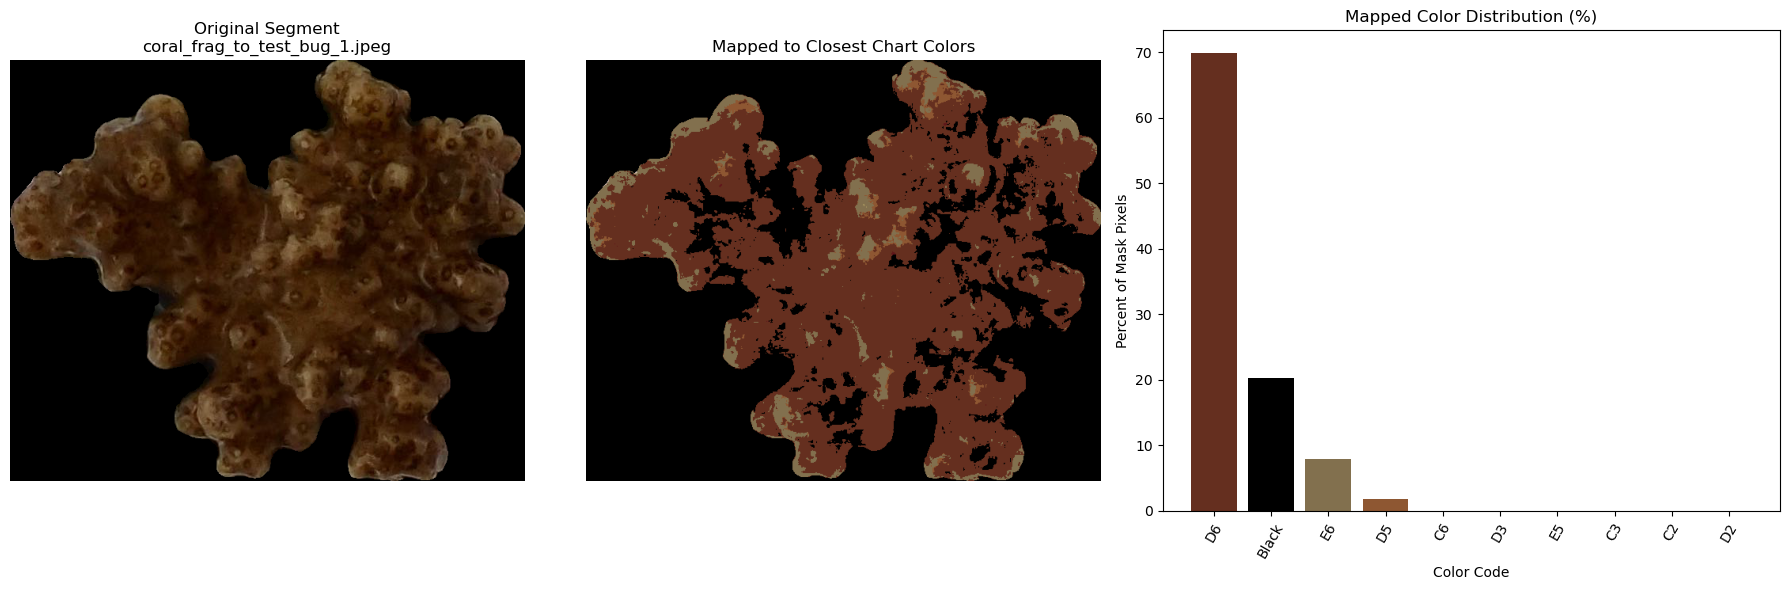

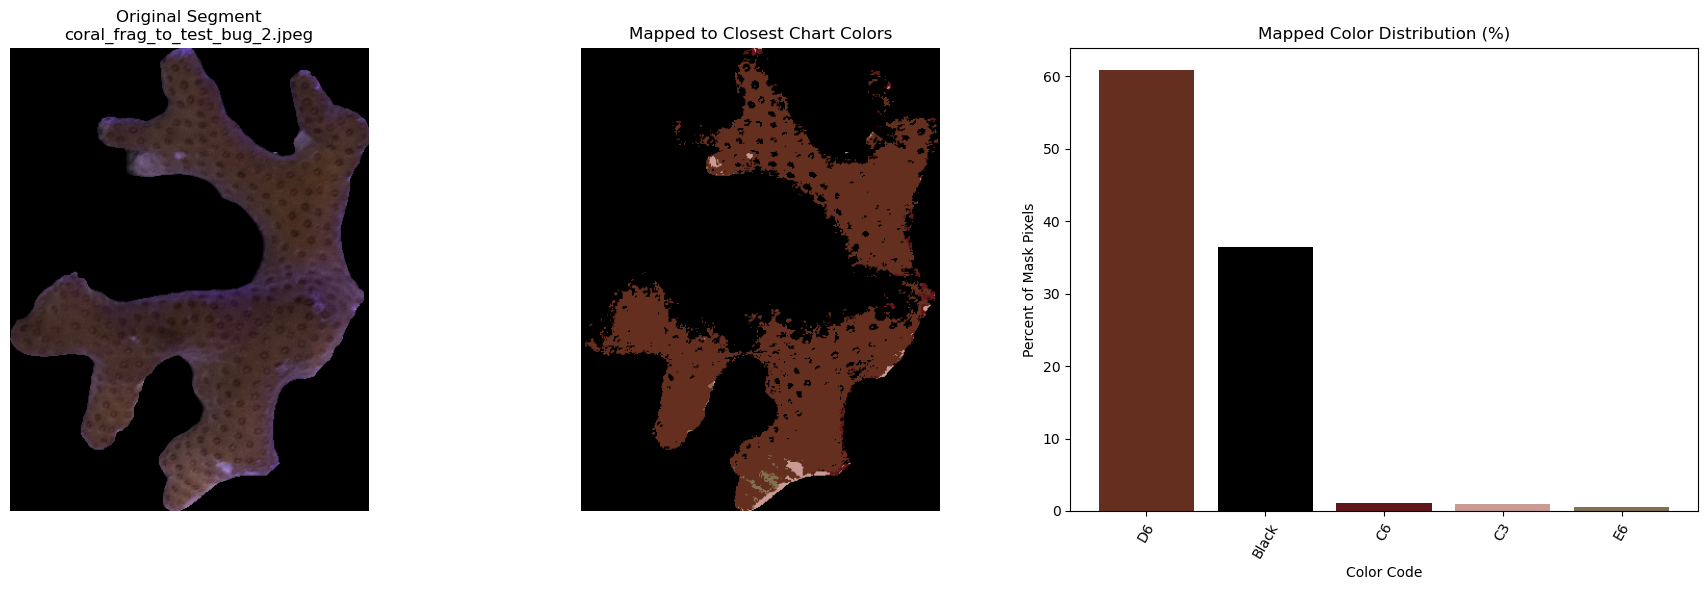


Top mapped colors for coral_frag_to_test_bug_1.jpeg


,Color Name,RGB,Percentage
0,D6,"(101, 47, 31)",69.860805
1,Black,"(0, 0, 0)",20.330079
2,E6,"(130, 112, 78)",7.955335
3,D5,"(142, 87, 50)",1.802687
4,C6,"(96, 22, 26)",0.028772
5,D3,"(189, 164, 136)",0.008929
6,E5,"(159, 141, 92)",0.003968
7,C3,"(201, 155, 148)",0.003472
8,C2,"(204, 187, 181)",0.003472
9,D2,"(189, 183, 165)",0.002480



Top mapped colors for coral_frag_to_test_bug_2.jpeg


,Color Name,RGB,Percentage
0,D6,"(101, 47, 31)",60.922851
1,Black,"(0, 0, 0)",36.399067
2,C6,"(96, 22, 26)",1.133215
3,C3,"(201, 155, 148)",1.000172
4,E6,"(130, 112, 78)",0.544695


In [7]:
# Matplotlib equivalent of mapped-image + color distribution (no Streamlit required)
# This version includes Black as a valid mapped class inside the foreground mask.

def plot_compare_mapped_image_matplotlib(img_rgb, color_map_rgb, title, foreground_mask=None):
    mapped_img, full_color_map, _color_to_pixels = lf.map_color_to_pixels(
        img_rgb,
        color_map_rgb,
        foreground_mask=foreground_mask,
    )

    reverse_map = {tuple(v): k for k, v in full_color_map.items()}

    if foreground_mask is not None:
        mask = np.asarray(foreground_mask).astype(bool)
        flat = mapped_img[mask].reshape(-1, 3)
    else:
        flat = mapped_img.reshape(-1, 3)

    unique_colors, counts = np.unique(flat, axis=0, return_counts=True)
    color_rows = []
    for rgb, count in zip(unique_colors, counts):
        rgb_t = tuple(int(x) for x in rgb)
        color_name = reverse_map.get(rgb_t, "Unknown")
        color_rows.append((color_name, rgb_t, int(count)))

    if not color_rows:
        print(f"I don't know: no mapped pixels were found for {title}.")
        return mapped_img, pd.DataFrame(columns=["Color Name", "RGB", "Percentage"])

    total_pixels = sum(row[2] for row in color_rows)
    color_rows = [
        (name, rgb, (count / total_pixels) * 100.0)
        for name, rgb, count in color_rows
    ]
    color_rows.sort(key=lambda x: x[2], reverse=True)

    color_names = [r[0] for r in color_rows]
    color_rgbs = [r[1] for r in color_rows]
    percentages = [r[2] for r in color_rows]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={"width_ratios": [1, 1, 1.2]})

    axes[0].imshow(img_rgb)
    axes[0].set_title(f"Original Segment\n{title}")
    axes[0].axis("off")

    axes[1].imshow(mapped_img)
    axes[1].set_title("Mapped to Closest Chart Colors")
    axes[1].axis("off")

    bar_colors = [np.array(rgb) / 255.0 for rgb in color_rgbs]
    axes[2].bar(color_names, percentages, color=bar_colors)
    axes[2].set_title("Mapped Color Distribution (%)")
    axes[2].set_xlabel("Color Code")
    axes[2].set_ylabel("Percent of Mask Pixels")
    axes[2].tick_params(axis="x", rotation=60)

    plt.tight_layout()
    plt.show()

    out_df = pd.DataFrame({
        "Color Name": color_names,
        "RGB": color_rgbs,
        "Percentage": percentages,
    })
    return mapped_img, out_df


# Render for each selected segmented coral image
mapped_images_matplotlib = {}
mapped_stats_matplotlib = {}

for image_name, seg_img in selected_segmented_crops.items():
    image_title = os.path.basename(image_name)
    fg_mask = selected_segmented_masks[image_name]
    mapped_img, stats_df = plot_compare_mapped_image_matplotlib(
        seg_img,
        custom_color_chart,
        title=image_title,
        foreground_mask=fg_mask,
    )
    mapped_images_matplotlib[image_name] = mapped_img
    mapped_stats_matplotlib[image_name] = stats_df

# Show compact stats table preview
for image_name, stats_df in mapped_stats_matplotlib.items():
    print(f"\nTop mapped colors for {os.path.basename(image_name)}")
    display(stats_df.head(10))

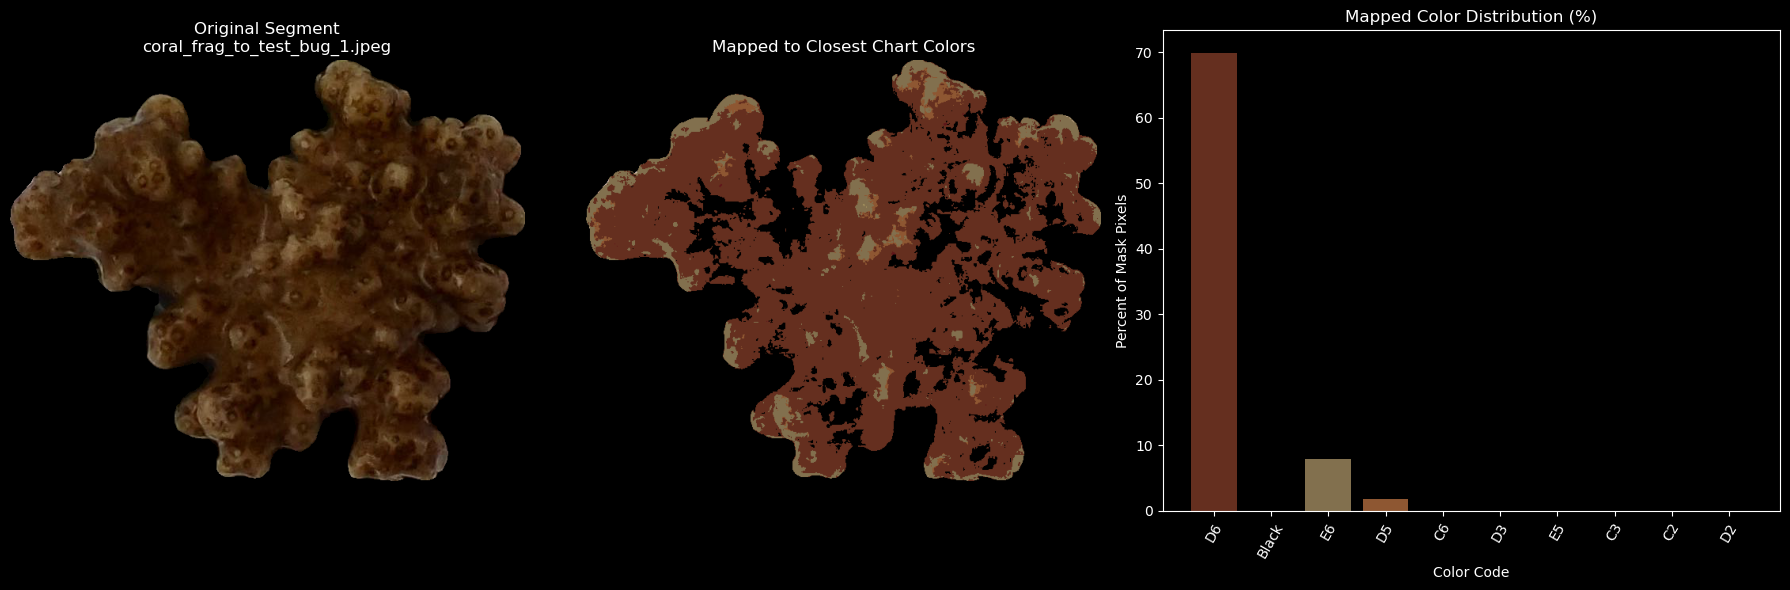

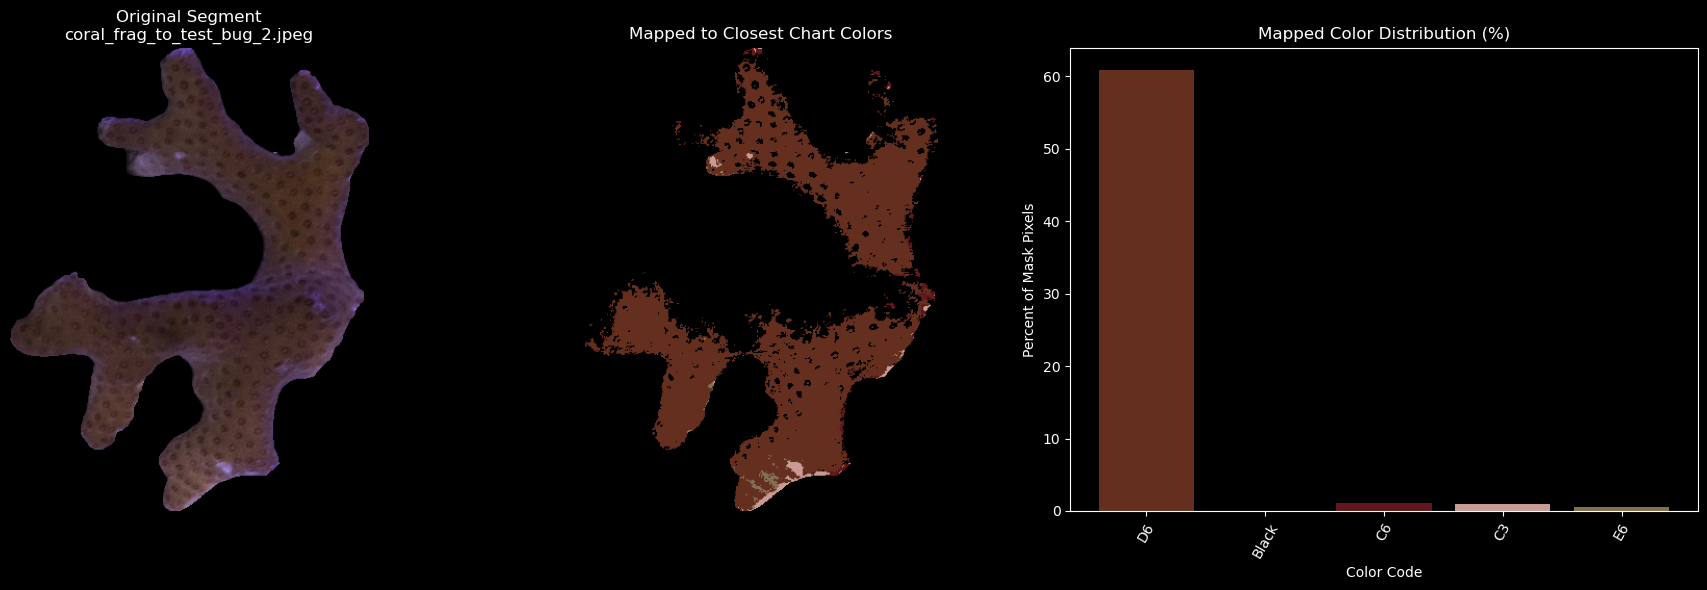


Top mapped colors for coral_frag_to_test_bug_1.jpeg


,Color Name,RGB,Percentage
0,D6,"(101, 47, 31)",69.860805
1,Black,"(0, 0, 0)",20.330079
2,E6,"(130, 112, 78)",7.955335
3,D5,"(142, 87, 50)",1.802687
4,C6,"(96, 22, 26)",0.028772
5,D3,"(189, 164, 136)",0.008929
6,E5,"(159, 141, 92)",0.003968
7,C3,"(201, 155, 148)",0.003472
8,C2,"(204, 187, 181)",0.003472
9,D2,"(189, 183, 165)",0.002480



Top mapped colors for coral_frag_to_test_bug_2.jpeg


,Color Name,RGB,Percentage
0,D6,"(101, 47, 31)",60.922851
1,Black,"(0, 0, 0)",36.399067
2,C6,"(96, 22, 26)",1.133215
3,C3,"(201, 155, 148)",1.000172
4,E6,"(130, 112, 78)",0.544695


In [8]:
# Matplotlib version with black background for each panel
# This version includes Black as a valid mapped class inside the foreground mask.

def plot_compare_mapped_image_matplotlib_black_bg(img_rgb, color_map_rgb, title, foreground_mask=None):
    mapped_img, full_color_map, _color_to_pixels = lf.map_color_to_pixels(
        img_rgb,
        color_map_rgb,
        foreground_mask=foreground_mask,
    )

    reverse_map = {tuple(v): k for k, v in full_color_map.items()}

    if foreground_mask is not None:
        mask = np.asarray(foreground_mask).astype(bool)
        flat = mapped_img[mask].reshape(-1, 3)
    else:
        flat = mapped_img.reshape(-1, 3)

    unique_colors, counts = np.unique(flat, axis=0, return_counts=True)

    color_rows = []
    for rgb, count in zip(unique_colors, counts):
        rgb_t = tuple(int(x) for x in rgb)
        color_name = reverse_map.get(rgb_t, "Unknown")
        color_rows.append((color_name, rgb_t, int(count)))

    if not color_rows:
        print(f"I don't know: no mapped pixels were found for {title}.")
        return mapped_img, pd.DataFrame(columns=["Color Name", "RGB", "Percentage"])

    total_pixels = sum(row[2] for row in color_rows)
    color_rows = [
        (name, rgb, (count / total_pixels) * 100.0)
        for name, rgb, count in color_rows
    ]
    color_rows.sort(key=lambda x: x[2], reverse=True)

    color_names = [r[0] for r in color_rows]
    color_rgbs = [r[1] for r in color_rows]
    percentages = [r[2] for r in color_rows]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={"width_ratios": [1, 1, 1.2]})
    fig.patch.set_facecolor("black")

    for ax in axes:
        ax.set_facecolor("black")

    axes[0].imshow(img_rgb)
    axes[0].set_title(f"Original Segment\n{title}", color="white")
    axes[0].axis("off")

    axes[1].imshow(mapped_img)
    axes[1].set_title("Mapped to Closest Chart Colors", color="white")
    axes[1].axis("off")

    bar_colors = [np.array(rgb) / 255.0 for rgb in color_rgbs]
    axes[2].bar(color_names, percentages, color=bar_colors)
    axes[2].set_title("Mapped Color Distribution (%)", color="white")
    axes[2].set_xlabel("Color Code", color="white")
    axes[2].set_ylabel("Percent of Mask Pixels", color="white")
    axes[2].tick_params(axis="x", rotation=60, colors="white")
    axes[2].tick_params(axis="y", colors="white")

    for spine in axes[2].spines.values():
        spine.set_color("white")

    plt.tight_layout()
    plt.show()

    out_df = pd.DataFrame({
        "Color Name": color_names,
        "RGB": color_rgbs,
        "Percentage": percentages,
    })
    return mapped_img, out_df


mapped_images_black_bg = {}
mapped_stats_black_bg = {}

for image_name, seg_img in selected_segmented_crops.items():
    image_title = os.path.basename(image_name)
    fg_mask = selected_segmented_masks[image_name]
    mapped_img, stats_df = plot_compare_mapped_image_matplotlib_black_bg(
        seg_img,
        custom_color_chart,
        title=image_title,
        foreground_mask=fg_mask,
    )
    mapped_images_black_bg[image_name] = mapped_img
    mapped_stats_black_bg[image_name] = stats_df

for image_name, stats_df in mapped_stats_black_bg.items():
    print(f"\nTop mapped colors for {os.path.basename(image_name)}")
    display(stats_df.head(10))